In [1]:
import sys
sys.path.append('/Users/aidanmorson/Desktop/analysis/parkinsons/analysis')


In [26]:
import os
from load_data.load_npz import load_spikedata
from plotting import plot_rasters, plot_isi
from analysis import firing_sd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
sd24578_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24578_D49-6.zip')
sd24578_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24578_D60+6.zip')
sd24481_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24481_D49-6.zip')
sd24481_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24481_D60+6.zip')

(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='Neuron Index'>)

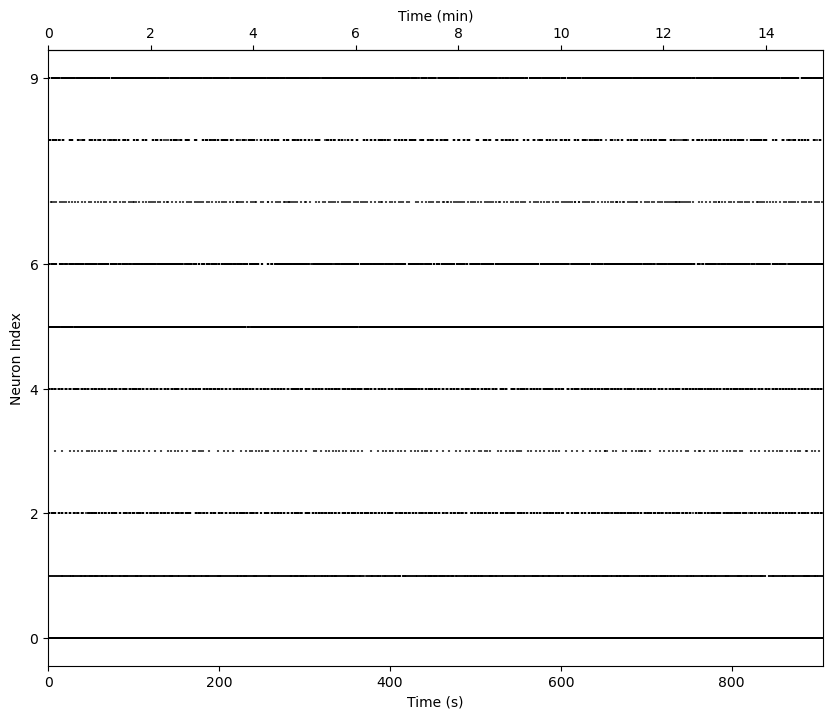

In [ ]:
plot_rasters.plot_raster(sd24578_49, [45, 48, 49, 65, 75, 90, 132, 165, 243, 295])

In [27]:
isi481_49 = firing_sd.isi(sd24481_49)

In [38]:
np.max(isi481_49)

228703.8

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Inter-Spike Interval (s)', ylabel='Count'>)

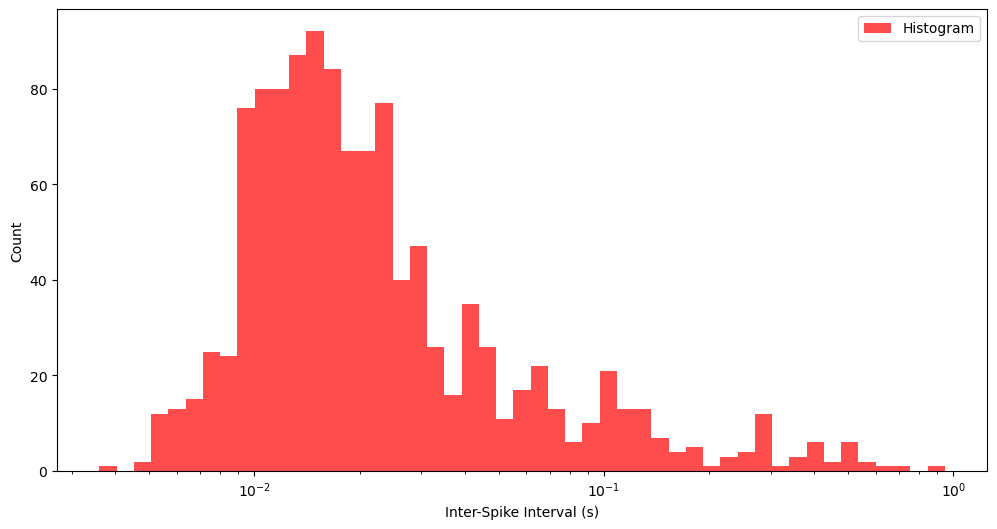

In [83]:
plot_isi.plot_isi_histogram(sd24578_49, time_window=(0,1), log_scale=True)

In [85]:
import numpy as np
import matplotlib.pyplot as plt

def compute_ccg_naive(trainA, trainB, bin_size=0.2, window=50):
    """
    Compute a cross-correlogram (CCG) between two spike trains using a naive loop-based method.
    
    Parameters:
        trainA : array-like
            Spike times for neuron A in milliseconds.
        trainB : array-like
            Spike times for neuron B in milliseconds.
        bin_size : float
            Bin size in ms (default 0.2 ms, corresponding to 200 µs).
        window : float
            Window in ms on each side of zero (default 50 ms).
            
    Returns:
        bin_centers : np.array
            The centers of the bins.
        counts : np.array
            The counts in each bin.
    """
    # Define bin edges from -window to +window (inclusive) with step = bin_size
    bin_edges = np.arange(-window, window + bin_size, bin_size)
    counts = np.zeros(len(bin_edges) - 1)
    
    # Loop over each spike in trainA
    for spike in trainA:
        # Compute differences between this spike and all spikes in trainB
        diffs = trainB - spike
        # Select differences within the window [-window, window]
        valid_diffs = diffs[(diffs >= -window) & (diffs <= window)]
        # Bin these differences
        hist, _ = np.histogram(valid_diffs, bins=bin_edges)
        counts += hist

    # Calculate bin centers for plotting
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    return bin_centers, counts


In [ ]:
trainA = sd24578_49.train[14]
trainB = sd24578_49.train[33]
bin_centers, counts = compute_ccg_naive(trainA, trainB, bin_size=0.2, window=50)


s

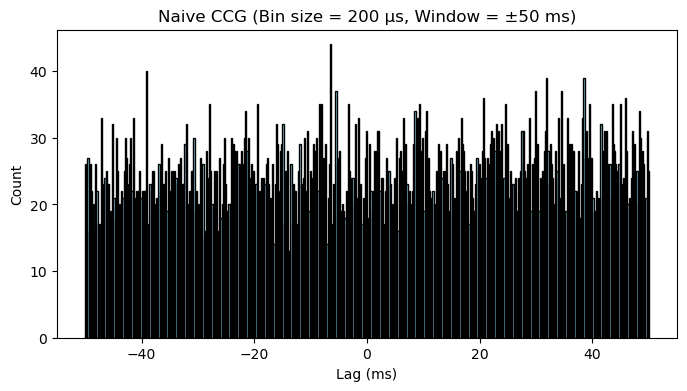

In [102]:
plt.figure(figsize=(8, 4))
plt.bar(bin_centers, counts, width=0.2, color="skyblue", edgecolor="k")
plt.xlabel("Lag (ms)")
plt.ylabel("Count")
plt.title("Naive CCG (Bin size = 200 µs, Window = ±50 ms)")
plt.show()